SGJobData


In [ ]:
#3. Setup 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/home/himike/NTU/SGJobData.csv", low_memory=False)

print(df.shape)          # Expect (~1048585, 20)
print(df.dtypes)
print(df.head(3))


In [ ]:
df['metadata_originalPostingDate'] = pd.to_datetime(df['metadata_originalPostingDate'])
df['metadata_newPostingDate'] = pd.to_datetime(df['metadata_newPostingDate'])
df['metadata_expiryDate'] = pd.to_datetime(df['metadata_expiryDate'])

In [ ]:
print(df.shape)
print(df.dtypes)

# Missing values
df.isnull().sum().sort_values(ascending=False).head(10)

# Basic stats
df[['salary_minimum','salary_maximum','average_salary',
    'minimumYearsExperience','numberOfVacancies']].describe()

(1048585, 22)
categories                                    object
employmentTypes                               object
metadata_expiryDate                   datetime64[ns]
metadata_isPostedOnBehalf                       bool
metadata_jobPostId                            object
metadata_newPostingDate               datetime64[ns]
metadata_originalPostingDate          datetime64[ns]
metadata_repostCount                           int64
metadata_totalNumberJobApplication             int64
metadata_totalNumberOfView                     int64
minimumYearsExperience                         int64
numberOfVacancies                              int64
occupationId                                 float64
positionLevels                                object
postedCompany_name                            object
salary_maximum                                 int64
salary_minimum                                 int64
salary_type                                   object
status_id                       

,salary_minimum,salary_maximum,average_salary,minimumYearsExperience,numberOfVacancies
count,1.048585e+06,1.048585e+06,1.048585e+06,1.048585e+06,1.048585e+06
mean,3.815312e+03,5.723578e+03,4.769445e+03,2.779573e+00,2.680043e+00
std,3.172182e+03,5.018387e+04,2.547809e+04,2.537049e+00,1.124301e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.500000e+03,3.300000e+03,2.900000e+03,1.000000e+00,1.000000e+00
50%,3.000000e+03,4.500000e+03,3.800000e+03,2.000000e+00,1.000000e+00
75%,4.500000e+03,6.500000e+03,5.500000e+03,4.000000e+00,2.000000e+00
max,3.500000e+05,2.533000e+07,1.266640e+07,8.800000e+01,9.990000e+02


In [ ]:
#5. Known data-quality landmines (read this!)
# Remove fake salary (1 = placeholder)
df = df[df['salary_minimum'] > 100]

# Remove extreme outliers using NumPy
p99 = np.percentile(df['average_salary'].dropna(), 99)
df = df[(df['average_salary'] > 500) & (df['average_salary'] <= p99)]

In [ ]:
import re

def extract_category(x):
    if pd.isna(x):
        return np.nan
    match = re.search(r'"category"\s*:\s*"([^"]+)"', str(x))
    return match.group(1) if match else np.nan

df['primary_category'] = df['categories'].apply(extract_category)

df['primary_category'].value_counts().head(10)

primary_category
Admin / Secretarial                 101592
Engineering                          99039
Information Technology               97679
Accounting / Auditing / Taxation     77675
Building and Construction            73628
Customer Service                     63710
F&B                                  58774
Banking and Finance                  44011
Logistics / Supply Chain             44004
Sales / Retail                       36564
Name: count, dtype: int64

In [ ]:
# Unique jobs
df['metadata_jobPostId'].nunique()

# Date range
df['metadata_originalPostingDate'].min(), df['metadata_originalPostingDate'].max()

# Top categories %
df['primary_category'].value_counts(normalize=True).head(10)

primary_category
Admin / Secretarial                 0.099048
Engineering                         0.096559
Information Technology              0.095233
Accounting / Auditing / Taxation    0.075730
Building and Construction           0.071784
Customer Service                    0.062115
F&B                                 0.057302
Banking and Finance                 0.042909
Logistics / Supply Chain            0.042902
Sales / Retail                      0.035648
Name: proportion, dtype: float64

In [ ]:
target = ['Information Technology', 'Healthcare', 'Accounting / Finance']

df_target = df[df['primary_category'].isin(target)].copy()

KeyError: 'primary_category'

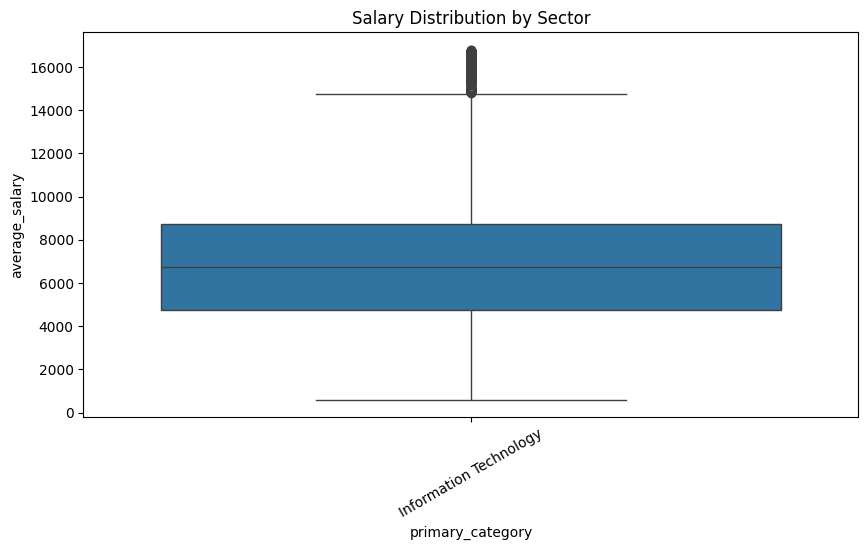

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_target, x='primary_category', y='average_salary')
plt.title("Salary Distribution by Sector")
plt.xticks(rotation=30)
plt.show()

Persona F — The Tech Sector Strategist
"I lead strategy at a tech company. I need a state-of-the-Singapore-tech-job-market report: who's hiring, for what skills, at what level, and how that has shifted over the last 18 months."

-	Filter to primary_category == 'Information Technology' (or similar). How many unique postings? What share of the whole market?
-	Use str.contains on the title column to tag roles: Engineer, Data, DevOps, Cloud, Cybersecurity, AI/ML. Plot a stacked bar chart of monthly demand by tag.
-	Show median salary trajectory over time (monthly) for the top 4 tech sub-roles. Has post-2023 demand shifted?
-	Which position levels are growing in tech vs declining? Use groupby(['year_month', 'positionLevels']).size() and a line chart.
